# Time Analysis



## Index
- [Time Analysis](#time-analysis)
  - [Loading libraries](#loading-libraries)
  - [Data Loading](#data-loading)
  - [Creating Grouped Tables for Temporal Analysis of Variables](#creating-grouped-tables-for-temporal-analysis-of-variables)
  - [Monthly and Yearly Aggregated Plots](#monthly-and-yearly-aggregated-plots)
    - [Range Plot: Min, Max, Average, and Last Year](#range-plot-min-max-average-and-last-year)
  - [Heatmap by Year and Month](#heatmap-by-year-and-month)
  - [Time Series Decomposition](#time-series-decomposition)
  - [Conclusions](#conclusions)

## Loading libraries

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggplot') 

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from visualization_scripts import seasonal_decomp_grapher, heatmap_grapher, barplot_grapher

## Data Loading

In [2]:
## Dowload DataSet:

data = pd.read_csv(str(Paths.DATA_PROCESSED)+"/preprocess_data.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather  year  month  \
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012      1   
1  2012-01-02           10.9      10.6       2.8   4.5     rain  2012      1   
2  2012-01-03            0.8      11.7       7.2   2.3     rain  2012      1   
3  2012-01-04           20.3      12.2       5.6   4.7     rain  2012      1   
4  2012-01-05            1.3       8.9       2.8   6.1     rain  2012      1   

   day  
0    1  
1    2  
2    3  
3    4  
4    5  


## Creating Grouped Tables for Temporal Analysis of Variables
Sometimes, depending on the type of analysis and other factors, it is necessary to group data to continue with the analysis. This happens a lot with the analysis of time series or locations such as cities or points of sale.

In this case, to see the behavior of the variables over the months and years, we make the following grouped tables.

In [3]:
# Goup by year-month
datapmonthyear = data.groupby(["month", "year"]).agg({
    "precipitation": "sum",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

# Goup by year
datapyear = datapmonthyear.groupby(["year"]).agg({
    "precipitation": "sum",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

# Goup by month
datapmont = data.groupby(["month"]).agg({
    "precipitation": "sum",
    "temp_max": "mean",
    "temp_min": "mean",
    "wind": "mean"
}).reset_index()

print(datapmonthyear.head(5))
print()
print(datapyear)
print()
print(datapmont)

   month  year  precipitation   temp_max  temp_min      wind
0      1  2012          173.3   7.054839  1.541935  3.829032
1      1  2013          105.7   6.106452  0.796774  2.835484
2      1  2014           94.0   9.600000  4.096774  3.122581
3      1  2015           93.0  10.154839  4.351613  2.429032
4      2  2012           92.3   9.275862  3.203448  3.744828

   year  precipitation   temp_max  temp_min      wind
0  2012         1226.0  15.262433  7.277823  3.357580
1  2013          828.0  16.023692  8.140363  2.986623
2  2014         1232.8  16.933719  8.618111  3.357972
3  2015         1139.2  17.393271  8.811050  3.137363

    month  precipitation   temp_max   temp_min      wind
0       1          466.0   8.229032   2.696774  3.054032
1       2          422.0   9.860177   4.054867  3.692920
2       3          606.2  12.387097   4.858871  3.558871
3       4          375.4  15.020000   6.362500  3.500833
4       5          207.5  19.295968   9.614516  3.120161
5       6          1

## Monthly and Yearly Aggregated Plots

Visualize the evolution of each variable over time by grouping data by month and year. These plots help detect long-term trends, seasonal behavior, and anomalies across different time scales.

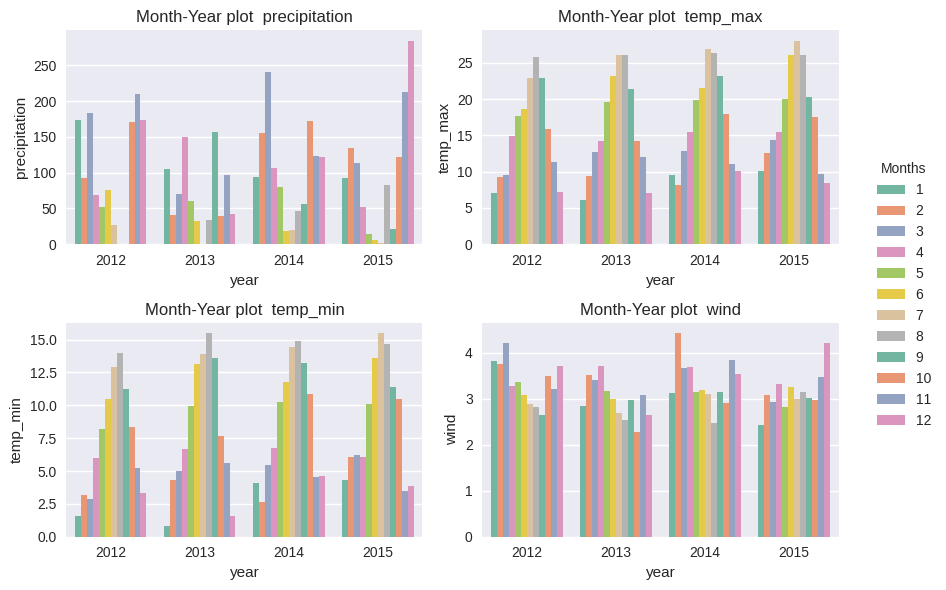

In [4]:
numerical_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']

barplot_grapher(datapmonthyear, numerical_columns, x_var="year", hue="month", 
                title_prefix="Month-Year plot ", legend_title = "Months")


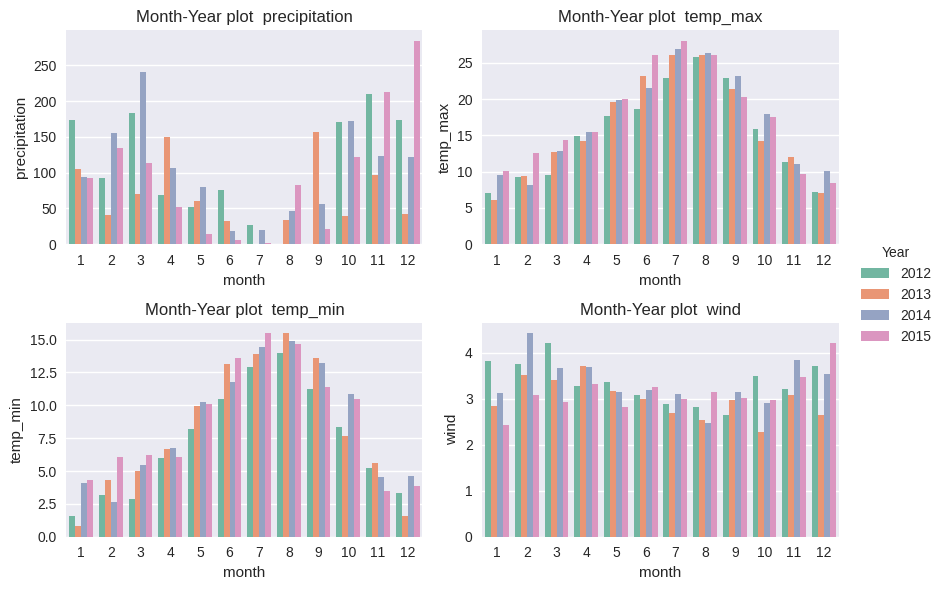

In [5]:
barplot_grapher(datapmonthyear, numerical_columns, x_var="month", hue="year", 
                title_prefix="Month-Year plot ", legend_title = "Year")

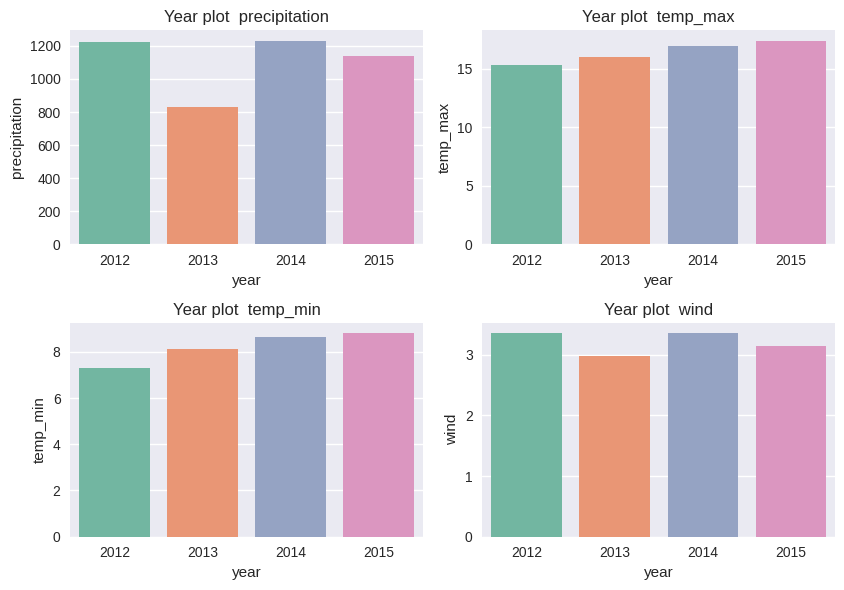

In [6]:
barplot_grapher(datapyear, numerical_columns, x_var="year", hue=None, 
                title_prefix="Year plot ")

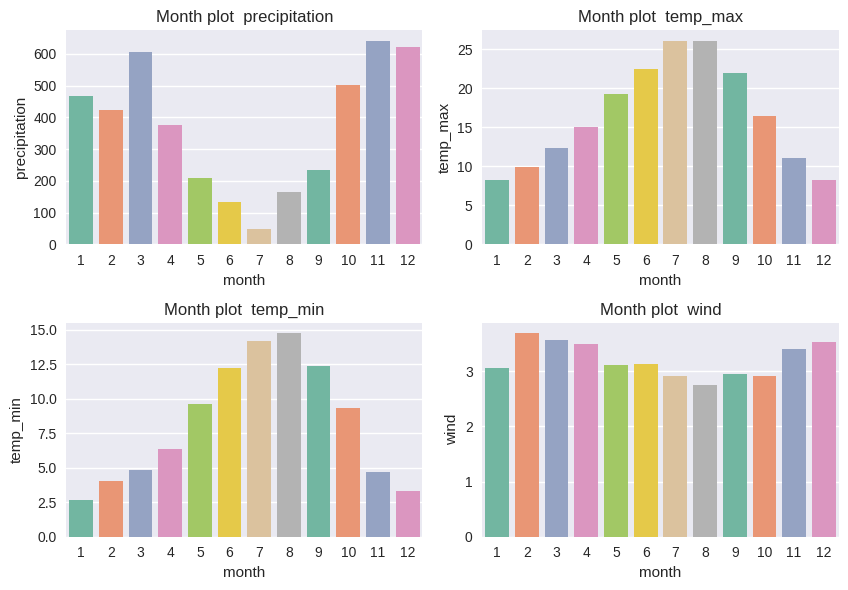

In [7]:
barplot_grapher(datapmont, numerical_columns, x_var="month", hue=None, 
                title_prefix="Month plot ")

### Range Plot: Min, Max, Average, and Last Year

Compare the variability of a variable across time using minimum, maximum, mean, and the most recent year. This type of plot highlights the typical fluctuation range and allows comparison with recent data to detect shifts or extremes.

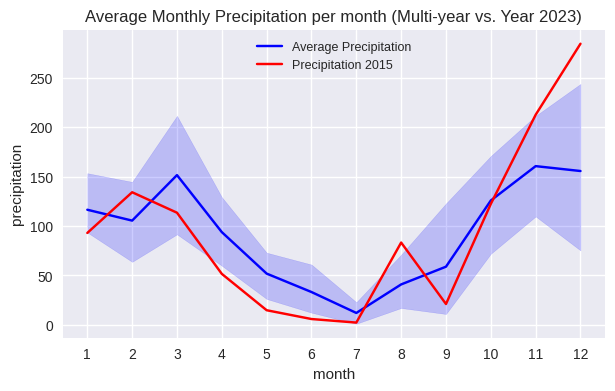

In [8]:
fig, ax = plt.subplots(figsize = (7,4))

sns.lineplot(data = datapmonthyear, x = "month", 
             y = "precipitation", color = "blue", ax = ax, label = "Average Precipitation")

dfr = datapmonthyear[datapmonthyear["year"] == 2015]

sns.lineplot(data = datapmonthyear[datapmonthyear["year"] == 2015], 
             x = "month", y = "precipitation", color="red", ax = ax, label = "Precipitation 2015")

ax.set_xticks(range(1, 13))
ax.set_title("Average Monthly Precipitation per month (Multi-year vs. Year 2023)")
ax.legend(loc="upper center",fontsize=9, ncol=1)
plt.show()

## Heatmap by Year and Month

Display a heatmap of average values per month and year. Heatmaps offer an intuitive way to detect repetitive patterns, seasonality, and abnormal periods through color intensity.

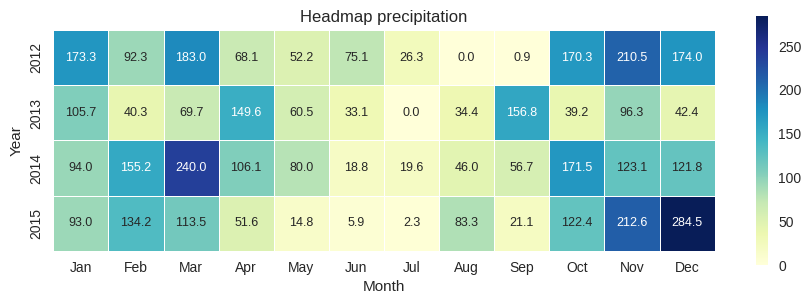

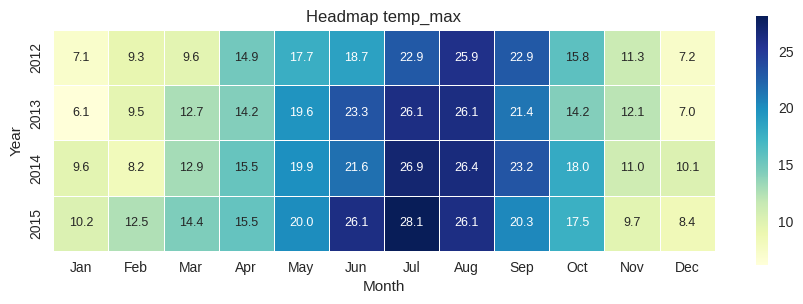

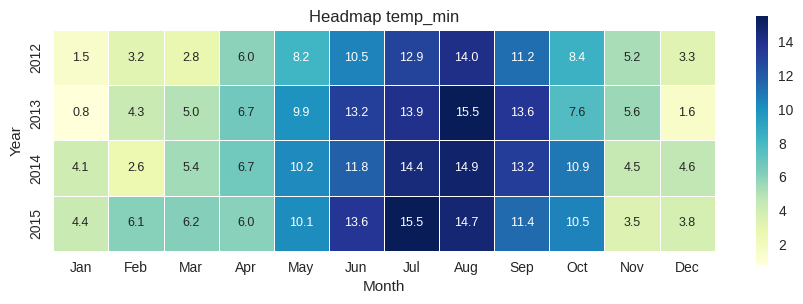

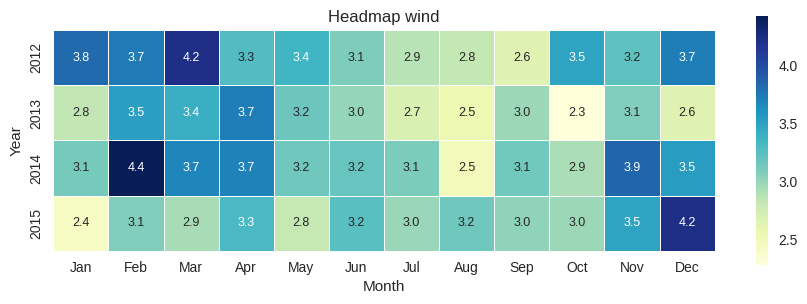

In [9]:
for i, var in enumerate(numerical_columns):
    heatmap_grapher(
        df=datapmonthyear,
        row_dim='year',
        col_dim='month',
        value_col=var,
        figsize=[9, 3],
        n_decimal=1,
        font_size=9,
        xlabel='Month',
        ylabel='Year',
        title = f'Headmap {var}'
    )

## Time Series Decomposition

Break down a time series into trend, seasonal, and residual components. Decomposition helps identify underlying cycles or regularities that are not visible in raw data, supporting better forecasting or pattern recognition.

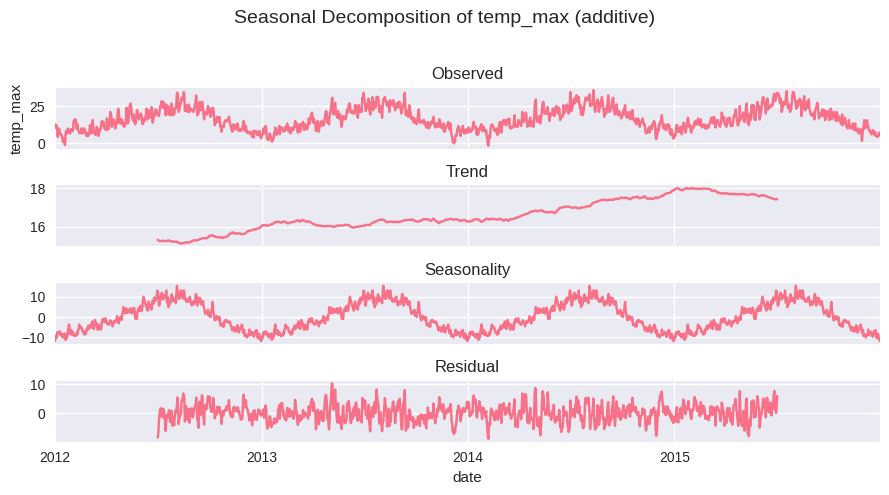

In [10]:
seasonal_decomp_grapher(
    df=data,
    date_col='date',
    value_col='temp_max',
    freq=365,
    model='additive'
)


## Conclusions

EN:

1. Climatic variables exhibit well-defined seasonal behavior, particularly maximum temperature (temp_max) and precipitation. Clear thermal peaks are consistently observed during summer months (June–August), while rainfall accumulates more heavily between December and February. This confirms a strong seasonal influence, which should be accounted for in predictive or explanatory modeling.

2. The range plot comparing historical min, max, mean, and latest year data shows that while recent precipitation values remain within historical bounds, certain months approach the upper extremes. This may suggest a subtle intensification of rainfall events in recent years.

3. The grouped plots by month and year highlighted significant interannual variability. Years like 2012 and 2014 exhibited unusually high precipitation in specific months, while 2015 appeared more moderate and stable across key variables.

4. Year-month heatmaps proved to be highly effective for temporal visualization. They enabled quick identification of critical months with extreme temperatures or precipitation, and reinforced the presence of long-term seasonal repetition.

5. STL decomposition of the temp_max time series revealed a strong and regular seasonal component, with clear yearly oscillations. The trend component shows a slight but steady increase in average maximum temperature over time, which could be aligned with local or regional climate change signals.

ES:

1. Las variables climáticas presentan patrones estacionales definidos, en particular la temperatura máxima temp_max y la precipitación. Se evidencian picos térmicos recurrentes en los meses de verano (junio–agosto), y acumulados de precipitación más altos concentrados entre diciembre y febrero. Esto sugiere una clara influencia de la estacionalidad en el comportamiento de estas variables, lo cual debe tenerse en cuenta en modelos predictivos.

2. El gráfico comparativo entre mínimos, máximos, promedio histórico y datos del último año permitió detectar que, si bien las precipitaciones del último año se encuentran dentro del rango histórico, tienden a acercarse a los máximos en algunos meses puntuales. Esto podría indicar una ligera intensificación de eventos lluviosos recientes.

3. Las gráficas agrupadas por mes y por año reflejan variabilidad dentro del año. Por ejemplo, años como 2012 y 2014 presentaron niveles anómalamente altos de precipitación en ciertos meses, mientras que 2015 muestra un comportamiento más moderado y estable en las principales variables.

4. Los mapas de calor (heatmaps) por año y mes mostraron ser herramientas efectivas para visualizar la distribución temporal de las variables. Estos permitieron identificar fácilmente meses críticos con temperaturas elevadas o lluvias excepcionales, así como evidenciar la estacionalidad en el largo plazo.

5. La descomposición de la serie de temperatura máxima (temp_max) usando STL reveló un componente estacional, con oscilaciones claramente anuales. El componente de tendencia indica una ligera pero sostenida alza en la temperatura máxima promedio a lo largo de los años, lo que podría ser consistente con patrones de cambio climático local o regional.


